<p align="center"><img src="https://github.com/uchiharon/ANN-Overfitting-Lab/blob/main/Images/University_of_Texas_at_Austin_seal.svg.png?raw=true" width="200" height="200" /></p>

# Forward Modeling -- Wave propagation

### **Emmanuel Ikpesu**
### **ei3294**
#### **Hildebrand Department of Petroleum and Geosystems Engineering, Cockrell School of Engineering**

# Q1.2 PINNs Forward

In [201]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.preprocessing import MinMaxScaler

from tqdm import tqdm

In [202]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

Using device: cuda


In [203]:
# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

# Define parameters and initial conditions

dx = 0.01
dt = 0.005
x = torch.arange(0, 1 + dx, dx)
t = torch.arange(0, 2.0 + dt, dt)

x_scaler = MinMaxScaler(feature_range=(-1, 1))
t_scaler = MinMaxScaler()

x_scaled = torch.tensor(x_scaler.fit_transform(x.reshape(-1, 1))).flatten()
t_scaled = torch.tensor(t_scaler.fit_transform(t.reshape(-1, 1))).flatten()

dx_scaled = x_scaled[1] - x_scaled[0]
dt_scaled = t_scaled[1] - t_scaled[0]

x_grid, t_grid = torch.meshgrid(x_scaled, t_scaled, indexing='ij')

# Collocation points
x_colloc = x_grid.float().reshape(-1, 1).to(device)
t_colloc = t_grid.float().reshape(-1, 1).to(device)

c = 1.0
u_x0 = torch.sin(torch.pi * x_scaled) + 0.5 * torch.sin(3 * torch.pi * x_scaled)
du_dtx0 = torch.zeros(len(x_scaled))
u_0t = torch.zeros(len(t_scaled))
u_Lt = torch.zeros(len(t_scaled))

In [204]:
torch.tensor([[1,1,2],[3,4,5]]).flatten().reshape(2,3)

tensor([[1, 1, 2],
        [3, 4, 5]])

In [205]:
min(x_scaled)

tensor(-1., dtype=torch.float64)

In [206]:
# Test CFL condition
CFL = c * dt / dx

print(f"CFL number: {CFL}")
if CFL > 1:
    raise ValueError("CFL condition not met! Reduce dt or increase dx.")

CFL number: 0.5


In [207]:
CFL_scaled = c * dt_scaled / dx_scaled
print(f"CFL number: {CFL_scaled.item():.4f}")
if CFL_scaled > 1:
    raise ValueError("CFL condition not met in scaled coordinates! Reduce dt or increase dx.")

CFL number: 0.1250


In [208]:
# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

class SimpleNN(nn.Module):
    """Standard feedforward neural network"""
    def __init__(self, hidden_size=20, n_layers=8):
        super().__init__()
        
        layers = []
        layers.append(nn.Linear(2, hidden_size))  # Input: (x, t)
        
        # Hidden layers
        for _ in range(n_layers):
            layers.append(nn.Tanh())  # Smooth activation (important!)
            layers.append(nn.Linear(hidden_size, hidden_size))
        
        layers.append(nn.Tanh())
        layers.append(nn.Linear(hidden_size, 1))  # Output: displacement u
        
        self.network = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.network(x)

In [209]:
# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

def physics_loss(model, x_colloc, t_colloc, c = 1.0):
    """Compute the physics-based loss for the wave equation"""
    # Enable gradients for collocation points
    # Ensure gradients are enabled for input
    x_colloc = x_colloc.clone().detach().to(device).requires_grad_(True)
    t_colloc = t_colloc.clone().detach().to(device).requires_grad_(True)

    # Predict displacement
    u_pred = model(torch.cat([x_colloc, t_colloc], dim=1))

    # First derivative
    dT_dx = torch.autograd.grad(outputs=u_pred, 
                            inputs=x_colloc, 
                            grad_outputs=torch.ones_like(u_pred), 
                            create_graph=True,
                            retain_graph=True)[0]

    dT_dt = torch.autograd.grad(outputs=u_pred, 
                            inputs=t_colloc,
                            grad_outputs=torch.ones_like(u_pred),
                            create_graph=True,
                            retain_graph=True)[0]
    
    # Second derivative
    d2T_dx2 = torch.autograd.grad(outputs=dT_dx, 
                               inputs=x_colloc, 
                               grad_outputs=torch.ones_like(dT_dx), 
                               create_graph=True,
                               retain_graph=True)[0]
    

    d2T_dt2 = torch.autograd.grad(outputs=dT_dt, 
                               inputs=t_colloc, 
                               grad_outputs=torch.ones_like(dT_dt), 
                               create_graph=True,
                               retain_graph=True)[0]
    

    # Wave equation residual: u_tt - c^2 * u_xx = 0
    residual = d2T_dt2 - (c ** 2) * d2T_dx2

    # Physics loss: Mean Squared Error of the residuals
    physics_loss_value = torch.mean(residual**2)

    return physics_loss_value

# Test the physics loss function
test_model = SimpleNN().to(device)

test_loss = physics_loss(test_model, x_colloc, t_colloc)

print(f"Physics loss (untrained model): {test_loss.item():.6f}")
print("This is large since the model hasn't learned the physics yet!")

Physics loss (untrained model): 0.000001
This is large since the model hasn't learned the physics yet!


In [216]:
# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

n_boundary = len(t_scaled) * 2
n_initial = len(x_scaled)

def boundary_loss(model, n_boundary):
    """Compute the boundary condition loss"""
    t_bc = torch.linspace(0, 1, n_boundary).to(device).reshape(-1, 1)
    u_left = model(torch.cat([torch.ones_like(t_bc).to(device) * -1, t_bc], dim=1))
    u_right = model(torch.cat([torch.ones_like(t_bc).to(device), t_bc], dim=1))
    bc_loss = torch.mean(u_left**2 + u_right**2)
    return bc_loss


def initial_condition_loss(model, u_x0, n_initial):
    """Compute the initial condition loss"""
    # Initial displacement loss
    x_ic = torch.linspace(-1, 1, n_initial).to(device).reshape(-1, 1)
    t_ic = torch.zeros_like(x_ic).to(device).reshape(-1, 1).requires_grad_(True)

    u_pred_ic = model(torch.cat([x_ic, t_ic], dim=1))
    ic_loss = torch.mean((u_pred_ic.flatten() - u_x0.to(device))**2)

    # Initial velocity loss
    u_t_i = torch.autograd.grad(outputs=u_pred_ic, 
                                inputs=t_ic,
                                grad_outputs=torch.ones_like(u_pred_ic),
                                create_graph=True,
                                retain_graph=True)[0]
    
    ic_loss += 0.5 * torch.mean(u_t_i.flatten()**2)
    return ic_loss

def corner_loss(model):
    """Compute the corner condition loss"""
    corners_x  = torch.tensor([-1., -1., 1., 1.]).to(device).reshape(-1, 1)
    corners_t  = torch.tensor([-1., 1., -1., 1.]).to(device).reshape(-1, 1)
    corners = torch.cat([corners_x, corners_t], dim=1)
    u_corners = model(corners)
    corner_loss = torch.mean(u_corners**2)
    return corner_loss



# Test the boundary and initial condition loss function
test_model = SimpleNN().to(device)
bc_loss, ic_loss, c_loss = boundary_loss(test_model, n_boundary), initial_condition_loss(test_model, u_x0, n_initial), corner_loss(test_model)
print(f"Boundary loss (untrained model): {bc_loss.item():.6f}")
print(f"Initial condition loss (untrained model): {ic_loss.item():.6f}")
print(f"Corner loss (untrained model): {c_loss.item():.6f}")
print("This is large since the model hasn't learned the physics yet!")

Boundary loss (untrained model): 0.005796
Initial condition loss (untrained model): 0.621115
Corner loss (untrained model): 0.002867
This is large since the model hasn't learned the physics yet!


In [217]:
def train_model(model, x_colloc, t_colloc, u_x0, n_boundary, n_initial, epochs=5000, lr=1e-3, c=1.0, p_lambda=1.0
                , b_lambda=1.0, i_lambda=1.0, co_lambda=1.0):
    """Train the PINN model"""
    optimizer = optim.Adam(model.parameters(), lr=lr)

    physics_losses = []
    boundary_losses = []
    initial_losses = []
    corner_losses = []
    total_losses = []

    for epoch in tqdm(range(epochs)):
        optimizer.zero_grad()

        p_loss = physics_loss(model, x_colloc, t_colloc, c)
        b_loss = boundary_loss(model, n_boundary)
        i_loss = initial_condition_loss(model, u_x0, n_initial)
        c_loss = corner_loss(model)

        total_loss = p_lambda * p_loss + b_lambda * b_loss + i_lambda * i_loss + co_lambda * c_loss

        physics_losses.append(p_loss.item())
        boundary_losses.append(b_loss.item())
        initial_losses.append(i_loss.item())
        corner_losses.append(c_loss.item())
        total_losses.append(total_loss.item())

        total_loss.backward()
        optimizer.step()

        if epoch % 500 == 0:
            print(f"Epoch {epoch}, Total Loss: {total_loss.item():.6f}, Physics Loss: {p_loss.item():.6f}, Boundary Loss: {b_loss.item():.6f}, Initial Loss: {i_loss.item():.6f}, Corner Loss: {c_loss.item():.6f}")

    return model, physics_losses, boundary_losses, initial_losses, corner_losses, total_losses

Text(0.5, 1.0, 'Collocation Points')

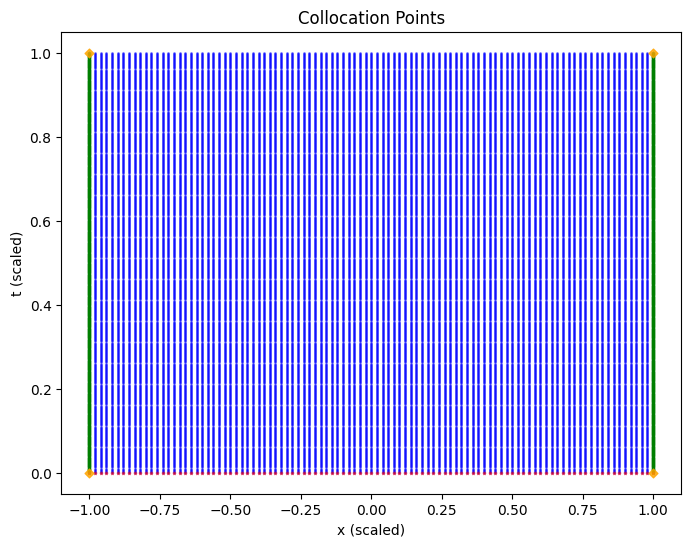

In [218]:
# Plot Collocation Points
plt.figure(figsize=(8, 6))

# Plot interior collocation points
plt.scatter(x_colloc.cpu().numpy(), t_colloc.cpu().numpy(), s=1, color='blue', alpha=0.5)

# Plot boundary collocation points
bc_t = torch.linspace(0, 1, n_boundary).to(device).reshape(-1, 1)
x_left = torch.ones_like(bc_t).to(device) * -1
x_right = torch.ones_like(bc_t).to(device)
plt.scatter(x_left.cpu().numpy(), bc_t.cpu().numpy(), s=4, color='green', alpha=0.5, marker='*', label='Boundary condition')
plt.scatter(x_right.cpu().numpy(), bc_t.cpu().numpy(), s=4, color='green', alpha=0.5, marker='*', label='Boundary condition')

# Plot initial condition points
ic_x = torch.linspace(-1, 1, n_initial).to(device).reshape(-1, 1)
t_initial = torch.zeros_like(ic_x).to(device).reshape(-1, 1)
plt.scatter(ic_x.cpu().numpy(), t_initial.cpu().numpy(), s=4, color='red', alpha=0.5, marker='*', label='Initial condition')

# Plot corner points
corners_x  = torch.tensor([-1., -1., 1., 1.]).to(device).reshape(-1, 1)
corners_t  = torch.tensor([0., 1., 0., 1.]).to(device).reshape(-1, 1)
plt.scatter(corners_x.cpu().numpy(), corners_t.cpu().numpy(), s=20, color='orange', alpha=0.8, marker='D', label='Corner condition')

plt.xlabel('x (scaled)')
plt.ylabel('t (scaled)')

plt.title('Collocation Points')

In [254]:
# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

model = SimpleNN().to(device)

trained_model, physics_losses, boundary_losses, initial_losses, corner_losses, total_losses = train_model(
    model, x_colloc, t_colloc, u_x0, n_boundary, n_initial, epochs=2000, lr=1e-3
                            , p_lambda=1, b_lambda=5000.0, i_lambda=500.0, co_lambda=0.0)

  0%|          | 6/2000 [00:00<02:01, 16.46it/s]

Epoch 0, Total Loss: 339.536723, Physics Loss: 0.000001, Boundary Loss: 0.005796, Initial Loss: 0.621115, Corner Loss: 0.002867


 25%|██▌       | 506/2000 [00:11<00:33, 45.26it/s]

Epoch 500, Total Loss: 75.257199, Physics Loss: 18.186003, Boundary Loss: 0.000449, Initial Loss: 0.109647, Corner Loss: 0.031233


 50%|█████     | 1006/2000 [00:22<00:21, 46.18it/s]

Epoch 1000, Total Loss: 68.678475, Physics Loss: 15.967778, Boundary Loss: 0.000777, Initial Loss: 0.097656, Corner Loss: 0.022109


 75%|███████▌  | 1506/2000 [00:33<00:10, 46.69it/s]

Epoch 1500, Total Loss: 58.898479, Physics Loss: 13.781267, Boundary Loss: 0.000291, Initial Loss: 0.087329, Corner Loss: 0.006996


100%|██████████| 2000/2000 [00:44<00:00, 45.29it/s]


In [255]:
# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

# Make predictions
with torch.no_grad():
    u_pred_flat = trained_model(torch.cat([x_colloc, t_colloc], dim=1))
    u_pred = u_pred_flat.reshape(x.shape[0], t.shape[0]).cpu().numpy()


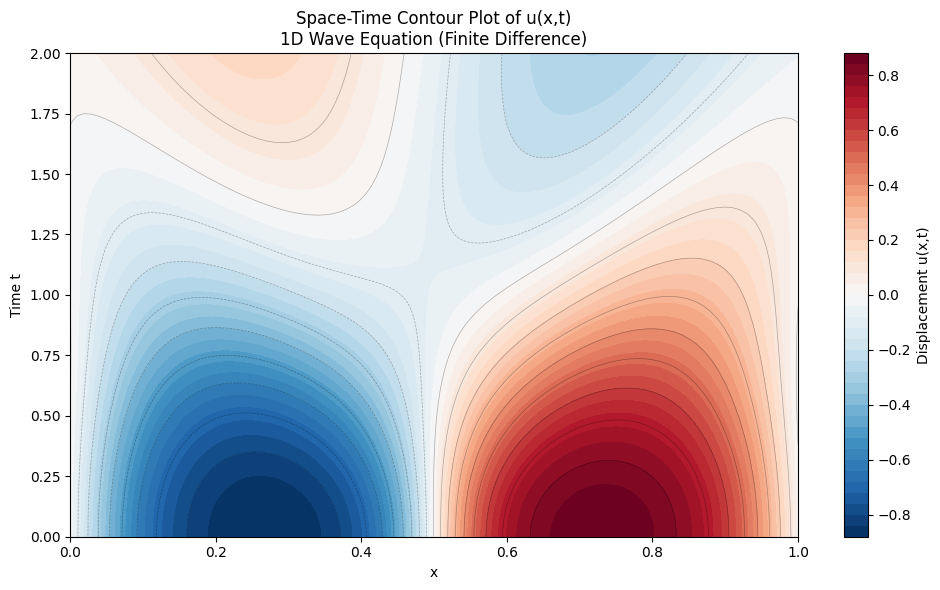

In [256]:
# Space-time contour plot
X, T_grid = np.meshgrid(x, t, indexing='ij')
plt.figure(figsize=(10, 6))
contour = plt.contourf(X, T_grid, u_pred, levels=50, cmap='RdBu_r')
plt.colorbar(contour, label='Displacement u(x,t)')
plt.contour(X, T_grid, u_pred, levels=20, colors='black', alpha=0.3, linewidths=0.5)
plt.xlabel('x')
plt.ylabel('Time t')
plt.title('Space-Time Contour Plot of u(x,t)\n1D Wave Equation (Finite Difference)')
plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Training Losses')

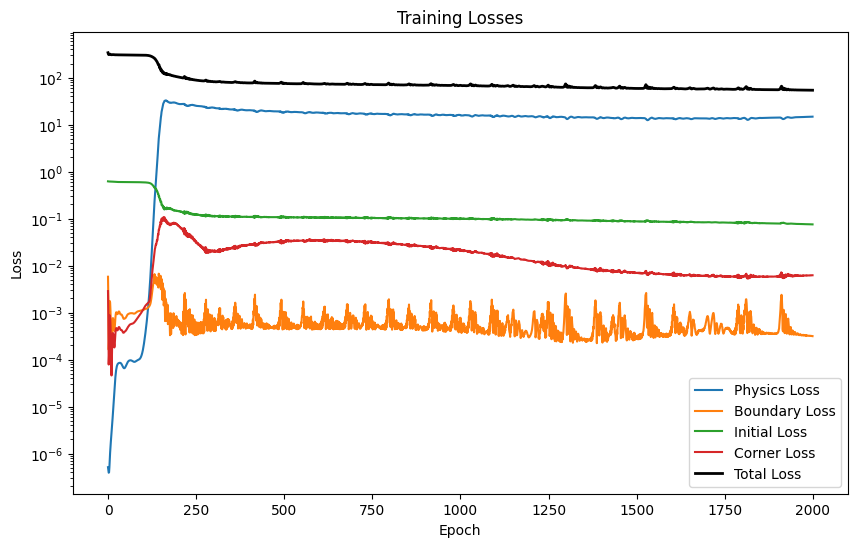

In [257]:
# Plot training losses
plt.figure(figsize=(10, 6))
plt.semilogy(physics_losses, label='Physics Loss')
plt.semilogy(boundary_losses, label='Boundary Loss')
plt.semilogy(initial_losses, label='Initial Loss')
plt.semilogy(corner_losses, label='Corner Loss')
plt.semilogy(total_losses, label='Total Loss', linewidth=2, color='black')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training Losses')